In [115]:
import numpy as np
from astropy.io import ascii
import matplotlib.pyplot as plt
def grmonty(file):
    """
    Reads SEDs in the format provided by grmonty. Ported from 
    the original SM script `plspec.m` provided by J. Dolence.
    
    Returns:
        lognu: Logarithmic frequency values
        ll: Logarithmic luminosity values in shape (6, s['colx'].shape)
    """
    LSUN = 3.827e33
    CL = 2.99792458e10
    ME = 9.1093826e-28
    HPL =  6.6260693e-27
    # Read the file using ascii
    s = ascii.read(file, format='no_header')


    # Array conversions for luminosity values (log10)
    ll = np.zeros((6, len(s)))  # Pre-allocate the array with shape (6, s['colx'].shape)
    ll[0] = np.array(s['col2'] * LSUN)
    ll[1] = np.array(s['col8'] * LSUN)
    ll[2] = np.array(s['col14']* LSUN)
    ll[3] = np.array(s['col20']* LSUN)
    ll[4] = np.array(s['col26']* LSUN)
    ll[5] = np.array(s['col32']* LSUN)
    
    tauabs = np.zeros((6, len(s)))  # Pre-allocate the array with shape (6, s['colx'].shape)
    tauabs[0] = np.array(s['col3'])    
    tauabs[1] = np.array(s['col9'])
    tauabs[2] = np.array(s['col15'])
    tauabs[3] = np.array(s['col21'])
    tauabs[4] = np.array(s['col27'])
    tauabs[5] = np.array(s['col33'])


    # Compute log frequency (log(nu)) values
    nu = np.array(10**s['col1'] * (ME * CL**2/HPL))
    #print(nu)
    # Return log(nu) and ll array
    return nu, ll, tauabs

#identify what folder i am in
#nu, nuLnu, tauabs = grmonty('/home/pedro/gpumontys/gpumonty_last/gpumonty/output/SPHERE_1e6.spec')
#nu_gr, nuLnu_gr = grmonty('/home/pedro/gpumontys/gpumonty_sphere/gpumonty/output/SPHERE.spec')
domega_array = np.array([4.281887e-01, 1.255386e+00, 1.997030e+00, 2.602581e+00, 3.030769e+00, 3.252416e+00])


In [116]:
import numpy as np
from scipy.special import kn  # For the modified Bessel function
from scipy.integrate import quad  # For integration

# Constants
M_SQRT2 = np.sqrt(2)
EE = 4.80320680e-10  # Electron charge in cgs
ME = 9.1093826e-28 # Electron mass in grams
CL = 2.99792458e10   # Speed of light in cm/s
JCST = M_SQRT2 * EE**3 / (27 * ME * CL**2)
CST = 1.88774862536  # 2^(11/12)
CL = 2.99792458e10  # Speed of light in cm/s
ME = 9.1093826e-28  # Electron mass in grams
HPL = 6.6260693e-27
THETAE_MIN = 0.3

# Parameters for emissivity tables
KMIN = 0.002
KMAX = 1e7
TMIN = 0.3
TMAX = 1e2
N_ESAMP = 2500
EPSABS = 0.
EPSREL = 1e-6
dlT = 1/(np.log(TMAX/TMIN)/N_ESAMP)
lT_min = np.log(TMIN)
# Initialize tables
F_table = np.zeros(N_ESAMP + 1)
K2_table = np.zeros(N_ESAMP + 1)

def jnu_integrand(th, K):
    """Integrand for the emissivity calculation."""
    sth = np.sin(th)
    x = K / sth
    if sth < 1.e-150 or x > 2.e8:
        return 0.
    #print("Inside integrand: sth =", sth, "and x = ", x)
    return sth**2 * (np.sqrt(x) + CST * x**(1. / 6.))**2 * np.exp(-x**(1. / 3.))

def init_emiss_tables():
    """Initialize emissivity and Bessel function tables."""
    global F_table, K2_table
    
    dlK = np.log(KMAX / KMIN) / N_ESAMP
    dlT = np.log(TMAX / TMIN) / N_ESAMP

    # Calculate F(K) table
    for k in range(N_ESAMP + 1):
        K = np.exp(k * dlK + np.log(KMIN))
        result, err = quad(jnu_integrand, 0, np.pi / 2, args=(K), epsabs=EPSABS, epsrel=EPSREL)
        F_table[k] = np.log(4 * np.pi * result)

    # Calculate K2(T) table (Bessel function values)
    for k in range(N_ESAMP + 1):
        T = np.exp(k * dlT + np.log(TMIN))
        K2_table[k] = np.log(kn(2, 1. / T))

    # Avoid divisions later
    global inv_dlK, inv_dlT
    inv_dlK = 1. / dlK
    inv_dlT = 1. / dlT


def K2_eval(Thetae):
    """Evaluate K2 using precomputed values and interpolation."""
    # Check if Thetae is less than the minimum or greater than the maximum
    if Thetae < TMIN:
        return 0.
    elif Thetae > TMAX:
        return 2. * Thetae * Thetae  # As per CUDA code

    if(Thetae == 100):
        return 1.999950006839e+04
    # Perform linear interpolation for the value of K2
    return linear_interp_K2(Thetae)

def linear_interp_K2(Thetae):
    """Linear interpolation for K2 evaluation."""
    # Calculate the index for the log of Thetae in the precomputed table
    lT = np.log(Thetae)
    
    # Compute the fractional index for interpolation
    di = (lT - lT_min) * inv_dlT  # Using inverse of dlT for better performance
    i = int(di)
    di = di - i  # Get the fractional part
    print(i, di)
    # Perform linear interpolation between the two closest table entries
    return np.exp((1. - di) * K2_table[i] + di * K2_table[i + 1])
    
KFAC = 9 * np.pi * ME * CL / EE

def linear_interp_F(K):
    """Linearly interpolate F_table for a given K value."""
    # Calculate the log of K and map it to the table index
    lK_min = np.log(KMIN)
    dlK = np.log(KMAX / KMIN) / N_ESAMP
    inv_dlK = 1.0 / dlK

    lK = np.log(K)
    di = (lK - lK_min) * inv_dlK
    i = int(di)
    di -= i  # Fractional part for interpolation

    # Boundary check to ensure interpolation remains within table range
    if i < 0 or i >= N_ESAMP:
        return 0.  # Return 0 if K is out of bounds (handled separately in F_eval)

    # Interpolate linearly between F_table[i] and F_table[i+1]
    result = np.exp((1.0 - di) * F_table[i] + di * F_table[i + 1])
    #print("Linear_interpo =", result, di, i);
    return result

def F_eval(Thetae, Bmag, nu):
    """Evaluate F using precomputed tables or approximation based on K."""
    # Calculate K based on input parameters
    K = KFAC * nu / (Bmag * Thetae**2)
    #print("K = ", K)
    if K > KMAX:
        # If K is beyond the table's range, return 0 as an approximation
        return 0.
    elif K < KMIN:
        # Use approximation for small K values
        x = K**(1 / 3)
        return x * (37.67503800178 + 2.240274341836 * x)
    else:
        # Use linear interpolation for values within table range
        return linear_interp_F(K)

def Bnu(nu, Thetae):
    """
    Calculates the Planck function B_nu at a given frequency nu and electron temperature Thetae.
    
    Parameters:
    nu (array-like): Frequency in Hz (can be an array).
    Thetae (float): Dimensionless electron temperature (Thetae = kT_e / m_e c^2).
    
    Returns:
    array: B_nu values for the given frequencies.
    """
    # Convert nu to a NumPy array if it's not already
    nu = np.array(nu, dtype=np.float64)
    
    # Calculate x = h * nu / (m_e * c^2 * Thetae)
    x = HPL * nu / (ME * CL**2 * Thetae)

    # Initialize result array
    result = np.zeros_like(x)
    
    # For x < 1e-3: use a series expansion to avoid numerical issues
    mask_low = x < 1e-3
    result[mask_low] = (2. * HPL * nu[mask_low]**3 / CL**2) / (
        x[mask_low] / 24. * (24. + x[mask_low] * (12. + x[mask_low] * (4. + x[mask_low])))
    )
    
    # For x >= 1e-3: use the standard formula
    mask_high = ~mask_low
    result[mask_high] = (2.0 * HPL * nu[mask_high]**3 / CL**2) / (np.float128(np.exp(np.float128(x[mask_high]))) - 1.0)
    
    return result
# Synchrotron emissivity function
def jnu(ne, nu, B, thetae):
    sin_value = 1
    nus = (2/9) * (EE * B/(2 * np.pi * ME * CL)) * thetae**2 * sin_value
    X = nu / nus
    factor = np.sqrt(2) * np.pi * EE**2 * ne * nus / (3 * CL * kn(2, 1/thetae))
    return factor * (X**(1/2) + 2**(11/12) * X**(1/6))**2 * np.exp(-X**(1/3))
# Example usage of F_eval within int_jnu calculation
def int_jnu(Ne, Thetae, Bmag, nu):
    """Calculate emissivity jnu using precomputed tables and F_eval, allowing nu to be an array."""
    # Ensure nu is an array
    nu = np.atleast_1d(nu)  # This converts scalars to a 1D array

    # Handle cases where Thetae is below the minimum threshold
    if Thetae < THETAE_MIN:
        return np.zeros_like(nu)

    # Get K2 using precomputed tables
    K2 = K2_eval(Thetae)
    if K2 == 0.:
        return np.zeros_like(nu)
    K2 = 1.999950006839e4
    # Calculate j_fac only once since it doesn't depend on nu
    j_fac = Ne * Bmag * Thetae**2 / K2

    # Compute F_eval for each value in the nu array
    F_vals = np.array([F_eval(Thetae, Bmag, n) for n in nu])
    # Calculate jnu for each nu value
    jnu_vals = JCST * j_fac * F_vals

    # If input was a scalar, return scalar output; otherwise, return array
    return jnu_vals[0] if jnu_vals.size == 1 else jnu_vals

# Initialize tables before calculations
init_emiss_tables()

In [117]:
import h5py

# Open the HDF5 file
with h5py.File('../../igrmonty/scattering_1e7.h5', 'r') as f:
    # Access the 'output' group
    output_group = f['output']
    LSUN = 3.827e33
    # Extract the datasets 'lnu' and 'nulnu'
    nu_igr = 10**output_group['lnu'][:] * (ME * CL**2/HPL)
    nuLnu_igr = output_group['nuLnu'][:] * LSUN
    dOmega_igr = output_group['dOmega'][:]

/tmp/ipykernel_3370/2078301135.py:41: RuntimeWarning: divide by zero encountered in divide
  diff = np.abs(y_simdata - y_igr_interp)/y_simdata
/tmp/ipykernel_3370/2078301135.py:41: RuntimeWarning: invalid value encountered in divide
  diff = np.abs(y_simdata - y_igr_interp)/y_simdata


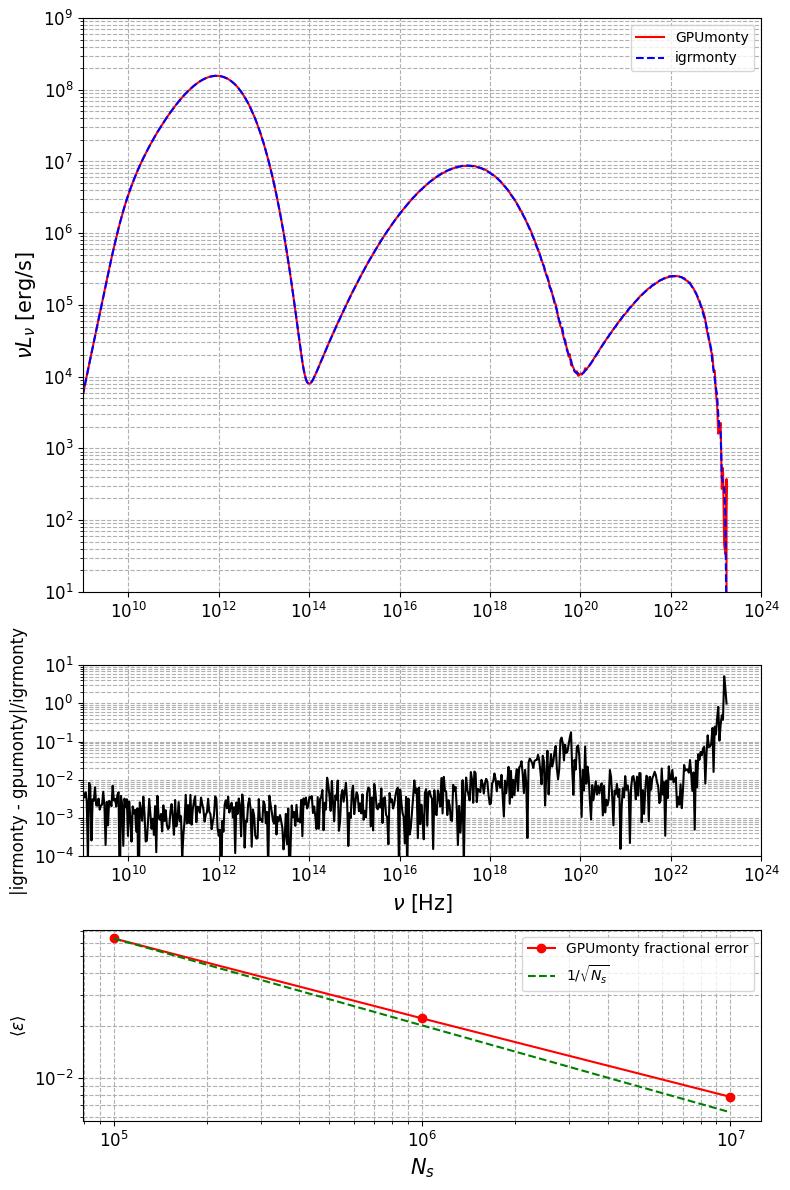

In [128]:
import numpy as np
import matplotlib.pyplot as plt

# Load your data
nu1e5, nuLnu1e5, tauabs = grmonty('../output/scattering_1e5')
nu1e6, nuLnu1e6, tauabs = grmonty('../output/testtt')
nu1e7, nuLnu1e7, tauabs = grmonty('../output/scattering_1e7')

# Simulation spectrum for the largest Ns (just for top panel)
y_simdata = (nuLnu1e7 * domega_array[:, None] / (4 * np.pi)).sum(0)

# igrmonty spectrum
y_igr = (nuLnu_igr.sum(0) * dOmega_igr / (4 * np.pi)).sum(1)

# Frequency limits for averaging
numin = 1e9
numax = 1e22
mask = (nu >= numin) & (nu <= numax)
nu_masked = nu[mask]

# --- Create figure with gridspec ---
fig = plt.figure(figsize=(8, 12))
gs = fig.add_gridspec(3, 1, height_ratios=[3, 1, 1])

# Top panel: spectra
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(nu, y_simdata, linestyle='-', color='red', label='GPUmonty')
ax1.plot(nu_igr, y_igr, linestyle='--', color='blue', label='igrmonty')
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_ylabel(r"$\nu L_\nu$ [erg/s]", fontsize=15)
ax1.grid(True, which="both", ls="--")
ax1.tick_params(axis='both', which='major', labelsize=12)
ax1.set_ylim(1e1, 1e9)
ax1.set_xlim(1e9, 1e24)
ax1.legend()

# Middle panel: relative difference
ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)
y_igr_interp = np.interp(nu, nu_igr, y_igr)
diff = np.abs(y_simdata - y_igr_interp)/y_simdata
ax2.plot(nu, diff, color='black')
ax2.axhline(0, color='gray', linestyle='--')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel(r"$\nu$ [Hz]", fontsize=15)
ax2.set_ylabel("|igrmonty - gpumonty|/igrmonty", fontsize=12)
ax2.grid(True, which="both", ls="--")
ax2.tick_params(axis='both', which='major', labelsize=12)
ax2.set_ylim(1e-4, 10)

# Bottom panel: fractional error vs Ns (independent x-axis)
ax3 = fig.add_subplot(gs[2, 0])
Ns_array = np.array([1e5, 1e6, 1e7])
y_list = [nuLnu1e5, nuLnu1e6, nuLnu1e7]
epsilon_avg_list = []

for y_sim in y_list:
    y_simdata = (y_sim * domega_array[:, None] / (4 * np.pi)).sum(0)
    y_igr_interp = np.interp(nu, nu_igr, y_igr)
    y_sim_masked = y_simdata[mask]
    y_igr_masked = y_igr_interp[mask]
    frac_error = np.abs(y_sim_masked - y_igr_masked) / y_igr_masked
    dlnnu = np.log(nu_masked[1:] / nu_masked[:-1])
    epsilon_avg = np.sum(frac_error[1:] * dlnnu) / np.log(numax/numin)
    epsilon_avg_list.append(epsilon_avg)

epsilon_avg_list = np.array(epsilon_avg_list)

# Plot epsilon_avg vs Ns
ax3.plot(Ns_array, epsilon_avg_list, 'o-', color='red', label='GPUmonty fractional error')
# 1/sqrt(Ns) reference line (normalized to first point)
ax3.plot(Ns_array, epsilon_avg_list[0]*(Ns_array[0]/Ns_array)**0.5, '--', color='green', label=r'1/$\sqrt{N_s}$')

ax3.set_xscale('log')
ax3.set_yscale('log')
ax3.set_xlabel(r"$N_s$", fontsize=15)
ax3.set_ylabel(r"$\langle \epsilon \rangle$", fontsize=12)
ax3.grid(True, which="both", ls="--")
ax3.legend()
ax3.tick_params(axis='both', which='major', labelsize=12)

plt.tight_layout()
#plt.savefig("spectra_comparison.png", dpi=300)  # save as PNG with high resolution
plt.show()


In [81]:
numax

1e+18

nuLnu.shape

In [6]:
np.max(nuLnu_igr[1])

10695334.526767446